# Retail Sales Analysis

**Version:** v0.3.0

**Author:** ArtoWare-Indonesia

## Project Overview

This project analyzes retail sales data using Python, Pandas, and Matplotlib to identify sales performance, customer behavior, regional trends, and product profitability.

### Data Source

The dataset used in this project is the Superstore dataset, sourced from Kaggle.

The dataset contains retail transaction records with information related to orders, customers, products, sales, quantity, discounts, profit, and geographic regions.

Source: Kaggle – Superstore

### Analysis Scope

This project covers the following stages:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights
- Conclusion

The analysis begins by preparing the Python environment and importing the required libraries for data processing, visualization, and file management.

### 1. Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from IPython.display import display

from google.colab import files

os.makedirs("data/processed", exist_ok=True)
os.makedirs("images", exist_ok=True)

plt.style.use("ggplot")

### 2. Load Dataset & Overview

This section provides an overview of the retail sales dataset, including its dimensions, data types, summary statistics, and a preview of the records before performing data cleaning and analysis.

The purpose of this step is to understand the structure, size, data types, statistical characteristics, and data quality of the dataset. This initial assessment helps identify potential issues that may need to be addressed during the data cleaning process.

#### 2.1 Choose and Upload Dataset

In [ ]:
uploaded = files.upload()

#### 2.2 Load and Preview Dataset

A preview of the dataset is displayed to examine the structure of individual records, understand the available columns, and identify the type of information contained in each transaction.

In [3]:
print(" Loading Dataset.......")

df = pd.read_csv("superstore.csv")

print("=" * 50)
print("Dataset Preview")
print("=" * 50)
display(df.head())

 Loading Dataset.......
Dataset Preview


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


From the dataset preview, we can see that the dataset contains 21 columns. In the next step, we will examine the dataset dimensions to understand its overall size.

#### 2.3 Dataset Dimension

The dataset dimensions are examined to determine the total number of rows and columns. This provides an understanding of the dataset size and helps establish the scope of the analysis.

In [4]:
print("Dataset Dimension (rows, columns) : ")

print(df.shape)

Dataset Dimension (rows, columns) : 
(9994, 21)


The dataset contains 9,994 rows and 21 columns. Now, let's examine the data types and non-null values of each column.

#### 2.4 Dataset Information

The dataset information is reviewed to examine column names, data types, and the number of non-null values. This helps identify potential data type inconsistencies and missing values that may require further investigation during data cleaning.

In [5]:
print("Dataset Information")
print("=" * 50)
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   f

The dataset contains 21 columns with 9,994 non-null values in each column, indicating that there are no missing values in the initial dataset. However, the `Order Date` and `Ship Date` columns are currently stored as `object` data types and will require conversion to datetime during the data cleaning process.

Now, let's examine the statistical characteristics of the numerical columns.


#### 2.5 Statistical Summary

Descriptive statistics are generated for numerical columns to understand the general characteristics and distribution of the data. Measures such as count, mean, standard deviation, minimum, and maximum values provide an initial understanding of the numerical variables.

In [6]:
print("Dataset Statistical Summary")
print("=" * 50)
display(df.describe())

Dataset Statistical Summary


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


The statistical summary provides an initial view of the numerical variables in the dataset. The `Sales` variable has an average value of 229.86, while `Profit` has an average value of 28.66. The `Profit` values range from -6,599.98 to 8,399.98, indicating that some transactions resulted in losses while others generated profits.

The wide range between the minimum and maximum values also suggests that the numerical variables may have different distributions and variations. These characteristics will be examined further during the exploratory data analysis.

Now, let's check for missing values in the dataset.


#### 2.6 Missing Value Check

Missing values are checked for each column to assess the completeness of the dataset. Identifying missing values at this stage helps determine whether additional data cleaning or handling is required before proceeding with the analysis.

In [7]:
print("Dataset Missing Value")
print("=" * 50)
print(df.isnull().sum())

Dataset Missing Value
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


The missing value check shows that all 21 columns contain 0 missing values. This indicates that the dataset is complete with respect to missing values, so no missing value treatment is required at this stage.

With the initial dataset overview completed, let's now proceed to the data cleaning process to check for other potential data quality issues, such as duplicate records and data type inconsistencies.


### 3. Data cleaning

Data cleaning is performed to ensure that the dataset is consistent, accurate, and ready for further analysis. Based on the initial dataset assessment, the dataset contains 9,994 records across 21 columns with no missing values. However, some columns, particularly `Order Date` and `Ship Date`, are still stored as object data types and require conversion to datetime.

In this section, the dataset will be cleaned by checking for duplicate records, validating data types, and making necessary transformations to improve data quality and consistency. The cleaned dataset will then be used as the basis for the Exploratory Data Analysis (EDA) and visualization stages.


#### 3.1 Check Duplicate Records

Duplicate records can cause certain transactions to be counted more than once and may affect the accuracy of the analysis. Therefore, the dataset is checked for duplicate rows to determine whether any identical records need to be removed before proceeding to the next cleaning steps.


In [8]:

print(df.duplicated().sum())

df = df.drop_duplicates()

0


The duplicate check returned **0 duplicate records**, indicating that no identical rows were found in the dataset. Therefore, no records were removed at this stage, and the dataset can proceed to the next data cleaning step.


#### 3.2 Data Type Conversion

The `Order Date` and `Ship Date` columns were initially stored as object data types. Since these columns represent transaction and shipping dates, they are converted to the `datetime` data type to ensure they can be properly used for date-based analysis, such as calculating time differences and analyzing sales trends over time.

After the conversion, the data types are checked to confirm that both columns have been successfully converted to datetime.


In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


The data type conversion was successful. Both `Order Date` and `Ship Date` are now stored as `datetime64[ns]`, allowing them to be used reliably for date-based analysis.

#### 3.3 Save Clean Dataset

After completing the data cleaning process, the cleaned dataset is saved as a separate CSV file to preserve the original raw dataset and provide a processed dataset for further analysis. The cleaned file is stored in the `data/processed` directory and will be used in the subsequent Exploratory Data Analysis (EDA) stage.


In [10]:
cleaned_path = "data/processed/superstore_clean.csv"

df.to_csv(cleaned_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_path}")

Cleaned dataset saved to: data/processed/superstore_clean.csv


The cleaned dataset has been successfully saved as `superstore_clean.csv` in the `data/processed` directory. This processed dataset will be used for the subsequent Exploratory Data Analysis (EDA) and visualization stages.

### 4. Exploratory Data Analysis

The data cleaning process has been completed. The dataset contains no missing values or duplicate records, and the Order Date and Ship Date columns have been successfully converted to the datetime data type. The cleaned dataset has also been saved for further analysis.

Exploratory Data Analysis (EDA) is performed to understand the main characteristics, patterns, and relationships within the cleaned dataset. The analysis focuses on sales performance, profitability, customer behavior, product performance, and trends over time.

The findings from this analysis will provide a foundation for identifying meaningful business insights and supporting data-driven conclusions.

#### 4.1 Feature Engineering

Before performing the main analysis, feature engineering is applied to create additional variables that support the analysis. In this project, the Order Date column is transformed into a monthly period to create the Order Month feature.

The Order Month feature will be used to analyze monthly sales trends and identify patterns in sales performance over time.

In [11]:

# Create a monthly period column from Order Date
df["Order Month"] = df["Order Date"].dt.to_period("M")

df[["Order Date", "Order Month"]].head()

,Order Date,Order Month
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


The `Order Month` feature has been successfully created from the `Order Date` column. The results show that each order has been assigned to its corresponding month, providing a suitable time-based feature for monthly sales analysis.


#### 4.2 Sales Analysis

Sales analysis is performed to understand the overall sales performance and identify patterns within the dataset. The analysis will examine sales across different categories, regions, customers, and time periods to identify areas that contribute most to the company's sales performance.

The results will help provide a clearer understanding of sales distribution and trends before moving to further profitability and product analysis.


##### 4.2.1 Total Sales

Total sales is calculated to provide an overall view of the sales performance across all transactions in the dataset. This metric serves as a baseline for the subsequent sales analysis and provides context for comparing sales across different categories, regions, customers, and time periods.


In [12]:
# Calculate total sales
total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


The dataset generated a total sales value of **$2,297,200.86** across all recorded transactions. This figure provides an overall baseline for evaluating sales performance and will be used as a reference for the subsequent analysis of sales by category, region, and time period.

##### 4.2.2 Sales by Category

Analyzing sales by product category helps identify which categories contribute the most to overall sales. This analysis provides a clearer view of the sales distribution across product categories and helps identify the strongest-performing categories within the dataset.


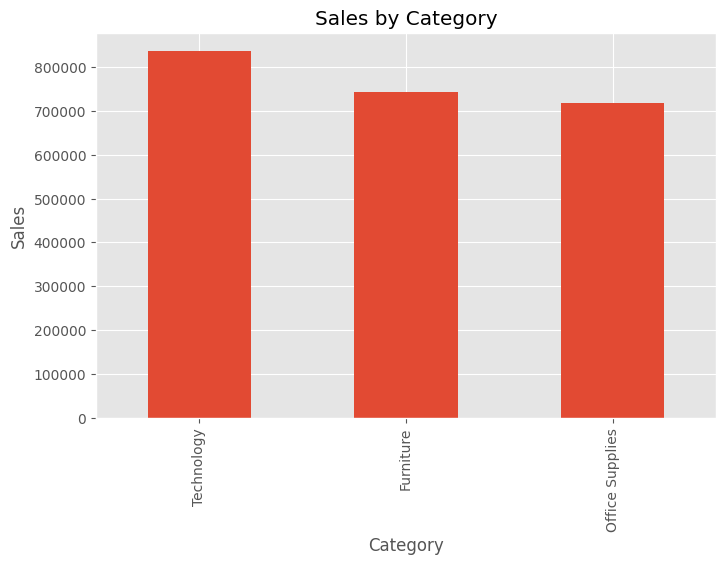

In [13]:
# sales by category
sales_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_category

sales_category.plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Category"
)

plt.ylabel("Sales")
plt.savefig("images/sales_category.png",dpi=300, bbox_inches="tight")
plt.show()

Technology generated the highest sales among the three product categories, followed by Furniture and Office Supplies. The difference between the categories is relatively moderate, indicating that sales are distributed across all three categories rather than being heavily concentrated in a single category.

##### 4.2.3 Sales by Region

Analyzing sales by region helps identify how sales are distributed geographically across the business. This analysis provides insights into regional sales performance and helps identify which regions contribute the most to overall sales.

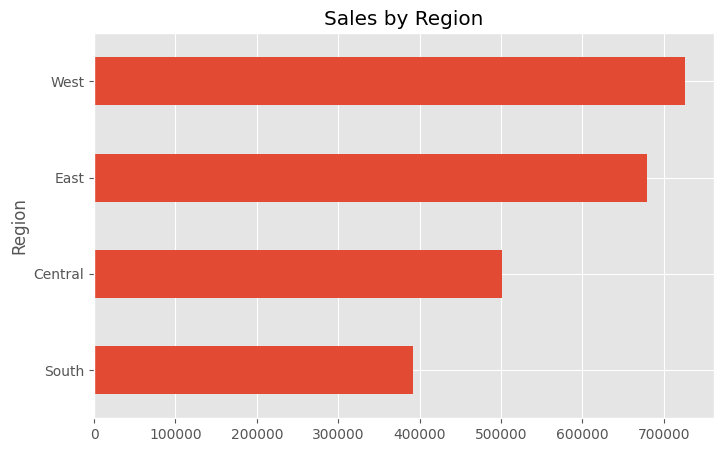

In [14]:
# sales by region
sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values()
)

sales_region.plot(
    kind="barh",
    figsize=(8,5),
    title="Sales by Region"
)
plt.savefig("images/sales_region.png", dpi=300, bbox_inches="tight")
plt.show()

The West region generated the highest sales, followed by the East, Central, and South regions. The results show that sales performance varies across regions, with the West contributing the largest share of overall sales while the South recorded the lowest sales.

##### 4.2.4 Monthly Sales Trend

Analyzing monthly sales trends helps identify how sales performance changes over time. This analysis uses the Order Month feature created during feature engineering to examine monthly sales patterns and identify periods of higher or lower sales activity.

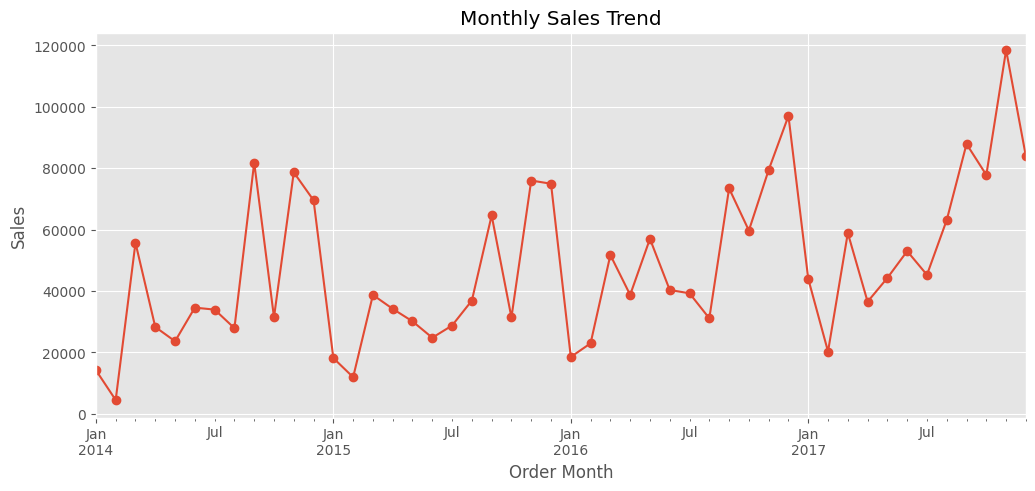

In [15]:
# Monthly sales trend
monthly_sales = (
    df.groupby("Order Month")["Sales"]
    .sum()
)

monthly_sales.plot(
    figsize=(12,5),
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Order Month")
plt.savefig("images/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

Monthly sales show considerable fluctuations throughout the observed period, with several noticeable peaks and declines. Overall, sales tend to reach higher levels toward the later years, particularly in 2016 and 2017. The highest monthly sales occur near the end of 2017, reaching approximately $118,000, while several of the lowest sales levels occur during the early months of the year. The recurring increases toward the end of several years may indicate a seasonal pattern in sales performance.

##### 4.2.5 Top 10 Customers

Analyzing sales by customer helps identify the customers who contribute the most to overall sales. This analysis focuses on the top 10 customers based on their total sales value, providing insight into the distribution of sales across the customer base and highlighting the most valuable customers by sales contribution.

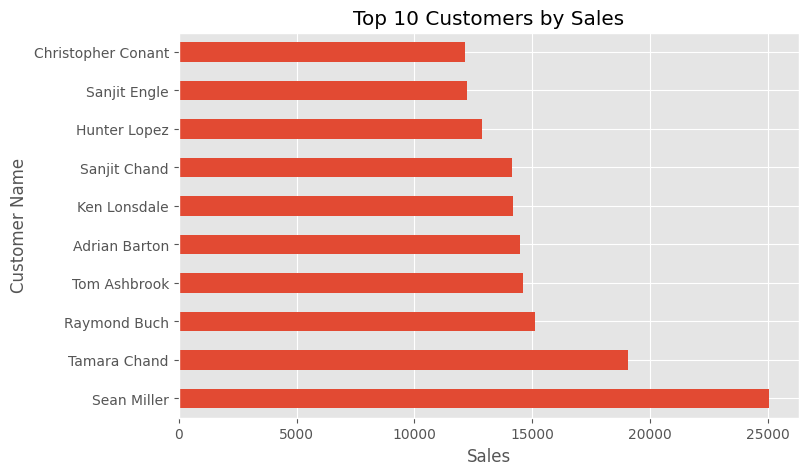

In [16]:
# Calculate total sales by customer
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .nlargest(10)
)

top_customers.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
plt.savefig("images/top_10_customers.png", dpi=300, bbox_inches="tight")
plt.show()

Sean Miller generated the highest sales among the top 10 customers, with sales of approximately 25,000 , followed by Tamara Chand at approximately 19,000. The remaining customers generated sales between approximately 12,000 and 15,000. This indicates that sales among the top 10 customers are relatively concentrated in a few leading customers, particularly Sean Miller and Tamara Chand.

##### 4.2.6 Top & Bottom Products

Analyzing product-level sales helps identify the products that contribute the most and the least to overall sales. This analysis compares the top-performing and bottom-performing products based on total sales, providing insight into product performance and sales distribution across the product portfolio.

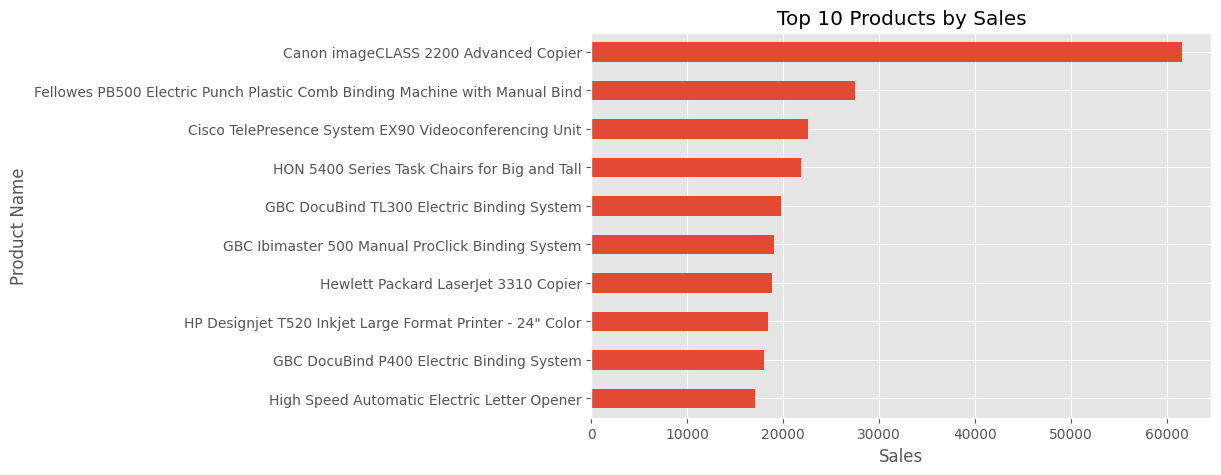

In [17]:
# Calculate total sales by product
sales_product = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Get top 10 products
top_products = sales_product.head(10)

top_products

top_products.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 10 Products by Sales"
)

plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.savefig(
    "images/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

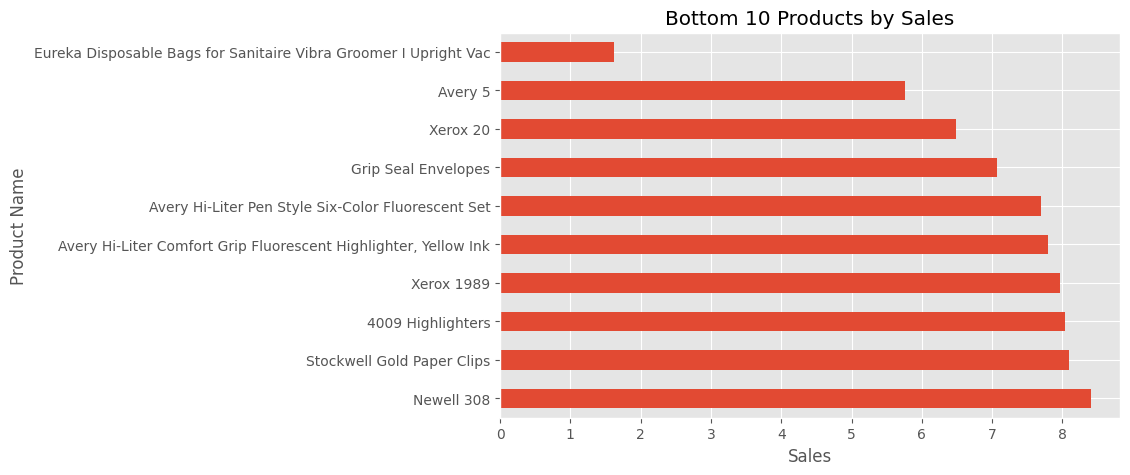

In [18]:
# Get bottom 10 products
bottom_products = sales_product.tail(10)

bottom_products

bottom_products.plot(
    kind="barh",
    figsize=(8, 5),
    title="Bottom 10 Products by Sales"
)

plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.savefig(
    "images/bottom_10_products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The top-performing products are dominated by high-value products, with the Canon imageCLASS 2200 Advanced Copier generating the highest sales at approximately 61,600. The remaining top products generated sales ranging from approximately 17,000 to $28,000.

In contrast, the bottom-performing products generated substantially lower sales. The lowest-selling product, Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac, generated less than 2 in sales, while most of the other bottom products generated sales below $9. This indicates a very large disparity in sales contribution across individual products.

#### 4.3 Profit Analysis

Sales performance alone does not provide a complete picture of business performance, as high sales do not necessarily result in high profitability. Profit analysis is therefore performed to evaluate the profitability of the business and identify patterns across different categories, regions, and products. This analysis will complement the sales analysis and provide a deeper understanding of the financial performance of the business.

##### 4.3.1 Total Profit

Total profit is calculated to provide an overall view of the profitability generated across all transactions in the dataset. This metric serves as a baseline for evaluating the company's financial performance and will be used as a reference for the subsequent profit analysis by category, region, and product.

In [19]:
# Calculate total profit
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


The dataset generated a total profit of $286,397.02 across all recorded transactions. This indicates that the business generated a positive overall profit during the observed period. The total profit provides a baseline for evaluating profitability across different categories, regions, and products in the following analysis.

##### 4.3.2 Profit Share by Category

Analyzing profit by product category helps identify which categories contribute the most to overall profitability. Comparing profit across categories also provides insight into whether the sales performance observed earlier is reflected in profitability.

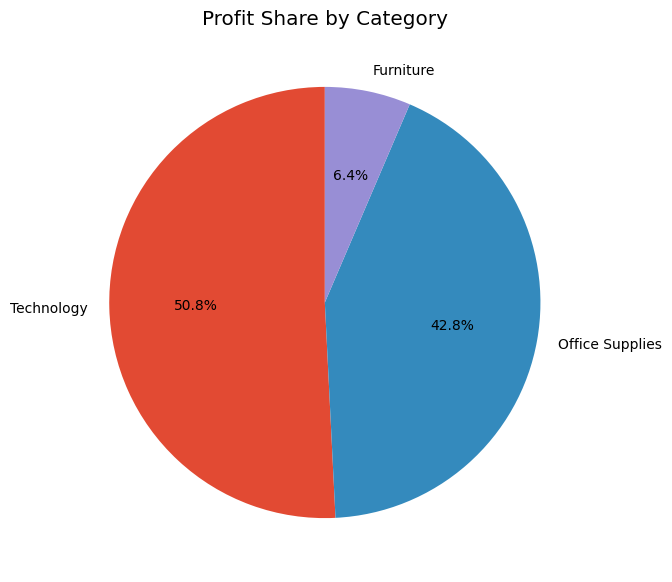

In [20]:
# Calculate total profit by category
profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_category

# Plot profit by category
profit_category.plot(
    kind="pie",
    figsize=(7, 7),
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Profit Share by Category")
plt.ylabel("")
plt.savefig(
    "images/profit_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Technology contributes the largest share of total profit at 50.8%, followed by Office Supplies at 42.8%, while Furniture contributes only 6.4%. This indicates that profitability is highly concentrated in the Technology and Office Supplies categories, with Technology accounting for more than half of the total profit.

The comparison between sales and profit reveals a significant difference in category performance. While Technology leads both sales and profit contribution, Office Supplies generates a substantially larger share of profit relative to its sales contribution. In contrast, Furniture contributes a similar share of sales but only 6.4% of total profit. This suggests that profitability varies considerably across product categories, highlighting the importance of analyzing profit alongside sales.

##### 4.3.3 Profit by Region

Analyzing profit by region helps identify how profitability is distributed across different geographic areas. By comparing regional profit performance with the sales results from the previous analysis, we can determine whether regions with higher sales also contribute more to overall profit.

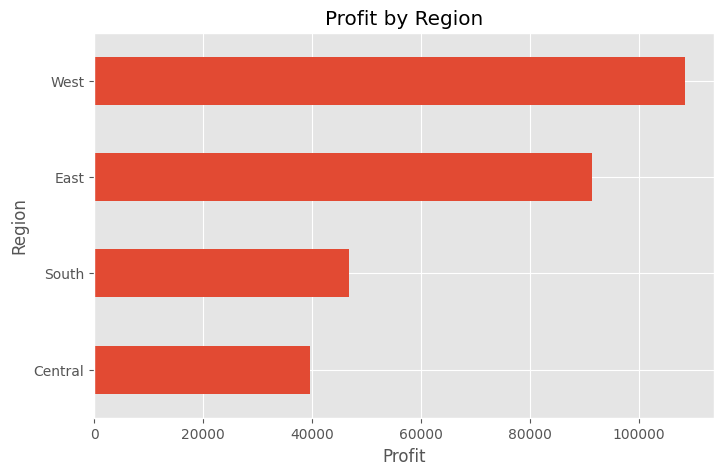

In [21]:
# Calculate total profit by region
profit_region = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values()
)

profit_region

# Plot profit by region
profit_region.plot(
    kind="barh",
    figsize=(8, 5),
    title="Profit by Region"
)

plt.xlabel("Profit")
plt.ylabel("Region")
plt.savefig(
    "images/profit_region.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The West region generated the highest profit at approximately 108,000 dollars, followed by the East region at approximately 91,000 dollars. The South and Central regions generated substantially lower profits, at approximately 47,000 dollars and 40,000 dollars respectively. This shows that profitability is concentrated in the West and East regions, which together contribute the majority of the total profit.

The comparison between sales and profit by region shows that higher sales generally correspond to higher profit in the West and East regions. However, the South region generates higher profit than the Central region despite having lower sales, suggesting differences in profitability across regions.

##### 4.3.4 Profit by Product

Analyzing profit by product helps identify which individual products contribute the most to overall profitability. This analysis complements the previous product sales analysis by examining whether products with high sales also generate substantial profit.

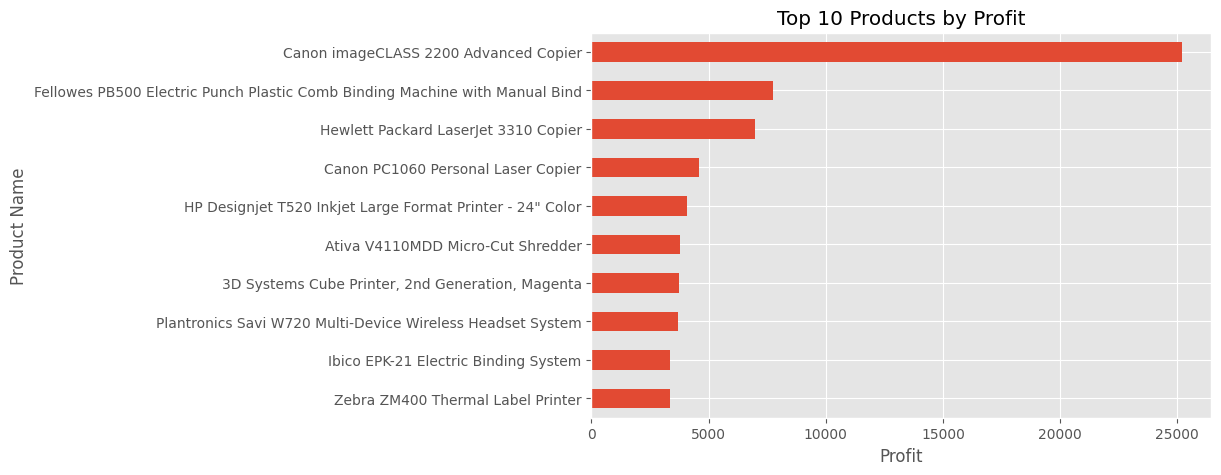

In [22]:
# Most Profitable Products
profit_product = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

# Get top 10 products by profit
top_profit_products = profit_product.head(10)

top_profit_products

# Plot top 10 products by profit
top_profit_products.sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Top 10 Products by Profit"
)

plt.xlabel("Profit")
plt.ylabel("Product Name")
plt.savefig("images/top_10_profit_products.png", dpi=300, bbox_inches="tight")
plt.show()

The Canon imageCLASS 2200 Advanced Copier generated the highest profit among all products, with approximately 25,000 dollars in profit. It is followed by the Fellowes PB500 Electric Punch Plastic Comb Binding Machine with approximately 7,700 dollars in profit and the Hewlett Packard LaserJet 3310 Copier with approximately 7,000 dollars. The remaining top products generated profits below $5,000.
The comparison between sales and profit rankings shows that some high-sales products also generate high profits, particularly the Canon imageCLASS 2200 Advanced Copier and the Fellowes PB500 Electric Punch Plastic Comb Binding Machine. However, the rankings are not identical, indicating that high sales do not always translate into equally high profit. This highlights differences in profitability across individual products.

### 5. Business Insights

The exploratory analysis revealed several important patterns in the company's sales and profitability performance. This section summarizes the key findings from the analysis and highlights relationships between sales, profit, product categories, regions, customers, and products.

#### 5.1 Sales and Profit by Category

Technology generated the highest sales and also contributed the largest share of total profit at 50.8%. However, Furniture generated a similar level of sales to Technology and Office Supplies while contributing only 6.4% of total profit. In contrast, Office Supplies contributed 42.8% of total profit despite having sales comparable to Furniture. This indicates substantial differences in profitability across product categories.

#### 5.2 Regional Performance

The West region recorded the highest sales and profit, while the East ranked second for both measures. However, the South region generated higher profit than the Central region despite having lower sales. This suggests that sales volume alone does not fully explain regional profitability.

#### 5.3 Product Performance

The Canon imageCLASS 2200 Advanced Copier was the highest-performing product in both sales and profit, generating approximately $61,600 in sales and 25,000 dollars in profit. However, the overall rankings of products by sales and profit were not identical, indicating that high sales do not always translate into proportionally high profit.

#### 5.4 Sales Trend Over Time

Monthly sales fluctuated considerably throughout the observed period, with generally higher sales levels in the later years, particularly 2016 and 2017. Several peaks occurred toward the end of the year, followed by declines in the early months of subsequent years. This pattern may indicate seasonal variations in sales performance.

### 6. Conclusion

The analysis demonstrates that sales performance and profitability do not always move proportionally. While Technology and the West region lead in both sales and profit, the substantial differences in profit contribution across categories, regions, and products show that evaluating sales alone may overlook important aspects of business performance. Overall, the analysis highlights the importance of considering both sales and profitability when evaluating business performance and identifying areas for improvement.